# Used Car Price Prediction using Machine Learning

# Table of Contents

- [Introduction](##Introduction)
- [Import Libraries](##Import-Libraries)
- [Load Dataset](##Load-Dataset)
- [Data Cleaning and Preprocessing](##Data-Cleaning-and-Preprocessing)
- [Feature Engineering](##Feature-Engineering)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Machine Learning](#Machine-Learning)
- [Feature Importance](##Feature-Importance)
- [Model Comparison](##Model-Comparison)
- [Model Demonstration](##Model-Demonstration)
- [Conclusion](##Conclusion)

## INTRODUCTION 

This project develops a machine learning model to predict the selling price of used cars based on their characteristics.
The resale value of a used car is influenced by several factors, including its age, original market price, mileage, fuel type, transmission, ownership history, and brand. Accurately predicting the selling price of used cars is an important application of machine learning, as it helps buyers, sellers, and dealerships estimate fair market values and make informed decisions.

In this project, Exploratory Data Analysis (EDA) is performed to understand the relationships between different vehicle characteristics and their influence on selling price. Data preprocessing techniques, including handling missing values, feature engineering, and encoding categorical variables, are applied to prepare the dataset for machine learning.

Three regression models—Linear Regression, Decision Tree Regression, and Random Forest Regression—are developed and evaluated using standard performance metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² Score. The objective is to identify the model that provides the most accurate predictions while gaining insights into the key factors affecting used car prices.

## IMPORT LIBRARIES 

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATASET

In [61]:
df = pd.read_csv("car data.csv")

## DATA CLEANING AND PREPROCESSING 

### Dataset visualization 

In [62]:
df.head()
df.shape
df.info()
df.describe 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


<bound method NDFrame.describe of     Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Selling_type Transmission  Owner  
0         Dealer       Manual      0  

### Finding missing values 

In [63]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

### Inspecting and removing duplicates

In [64]:
df.duplicated().sum()

np.int64(2)

In [65]:
df = df.drop_duplicates()


### Dataset visualization

In [66]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Selling_type   299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


### Analyzing categorical attributes 

In [68]:
df["Fuel_Type"].value_counts()


Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [69]:
df["Selling_type"].value_counts()


Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

In [70]:
df["Transmission"].value_counts()


Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

In [71]:
df["Owner"].value_counts()

Owner
0    288
1     10
3      1
Name: count, dtype: int64

## FEATURE ENGINEERING

In [72]:
df["Car_Age"] = 2025 - df["Year"]

C:\Users\pshim\AppData\Local\Temp\ipykernel_1352\3119388287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Car_Age"] = 2025 - df["Year"]


In [73]:
df[["Year","Car_Age"]].head()

,Year,Car_Age
0,2014,11
1,2013,12
2,2017,8
3,2011,14
4,2014,11


EXPLANATION:

From the attribute Year, we derive the colum Car Age. The new column makes it easier for us to compare the realtion between selling prices with how old the used car is in present time.

In [74]:
df["Car_Name"].unique()

array(['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
       's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis',
       '800', 'baleno', 'omni', 'fortuner', 'innova', 'corolla altis',
       'etios cross', 'etios g', 'etios liva', 'corolla', 'etios gd',
       'camry', 'land cruiser', 'Royal Enfield Thunder 500',
       'UM Renegade Mojave', 'KTM RC200', 'Bajaj Dominar 400',
       'Royal Enfield Classic 350', 'KTM RC390', 'Hyosung GT250R',
       'Royal Enfield Thunder 350', 'KTM 390 Duke ',
       'Mahindra Mojo XT300', 'Bajaj Pulsar RS200',
       'Royal Enfield Bullet 350', 'Royal Enfield Classic 500',
       'Bajaj Avenger 220', 'Bajaj Avenger 150', 'Honda CB Hornet 160R',
       'Yamaha FZ S V 2.0', 'Yamaha FZ 16', 'TVS Apache RTR 160',
       'Bajaj Pulsar 150', 'Honda CBR 150', 'Hero Extreme',
       'Bajaj Avenger 220 dtsi', 'Bajaj Avenger 150 street',
       'Yamaha FZ  v 2.0', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 220 F',
       'TVS Apache RTR 180', 

In [75]:
df["Brand"] = df["Car_Name"].str.split().str[0]

df[["Car_Name","Brand"]].head(10)

C:\Users\pshim\AppData\Local\Temp\ipykernel_1352\1719066597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Brand"] = df["Car_Name"].str.split().str[0]


,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift
5,vitara brezza,vitara
6,ciaz,ciaz
7,s cross,s
8,ciaz,ciaz
9,ciaz,ciaz


In [76]:
brand_map = {

    # Honda
    "city":"Honda",
    "brio":"Honda",
    "amaze":"Honda",
    "jazz":"Honda",

    # Hyundai
    "verna":"Hyundai",
    "creta":"Hyundai",
    "i20":"Hyundai",
    "i10":"Hyundai",
    "eon":"Hyundai",
    "xcent":"Hyundai",
    "elantra":"Hyundai",

    # Toyota
    "corolla":"Toyota",
    "camry":"Toyota",
    "fortuner":"Toyota",
    "innova":"Toyota",
    "etios":"Toyota",
    "land":"Toyota",      # Land Cruiser

    # Maruti Suzuki
    "ritz":"Maruti",
    "ciaz":"Maruti",
    "wagon":"Maruti",
    "swift":"Maruti",
    "vitara":"Maruti",
    "alto":"Maruti",
    "ertiga":"Maruti",
    "dzire":"Maruti",
    "ignis":"Maruti",
    "baleno":"Maruti",
    "omni":"Maruti",
    "800":"Maruti",
    "s":"Maruti",          # S Cross

    # Mahindra
    "xuv":"Mahindra",
    "scorpio":"Mahindra",
}

In [77]:
df["Brand"] = df["Brand"].replace(brand_map)

df[["Car_Name","Brand"]].head(20)

C:\Users\pshim\AppData\Local\Temp\ipykernel_1352\2266948442.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Brand"] = df["Brand"].replace(brand_map)


,Car_Name,Brand
0,ritz,Maruti
1,sx4,sx4
2,ciaz,Maruti
3,wagon r,Maruti
4,swift,Maruti
5,vitara brezza,Maruti
6,ciaz,Maruti
7,s cross,Maruti
8,ciaz,Maruti
9,ciaz,Maruti


**EXPLANATION:**

With the aim of of reducing the Car Name records, we derived the column Brand by using a defined dictionary, this allows us to see which car brands resell best or worst. 

In [78]:
df["Depreciation"] = df["Present_Price"] - df["Selling_Price"]

df[["Present_Price","Selling_Price","Depreciation"]].head()

C:\Users\pshim\AppData\Local\Temp\ipykernel_1352\3636399664.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Depreciation"] = df["Present_Price"] - df["Selling_Price"]


,Present_Price,Selling_Price,Depreciation
0,5.59,3.35,2.24
1,9.54,4.75,4.79
2,9.85,7.25,2.60
3,4.15,2.85,1.30
4,6.87,4.60,2.27


In [79]:
df["Depreciation_%"] = (
    (df["Present_Price"] - df["Selling_Price"])
    / df["Present_Price"]
) * 100

df[["Present_Price","Selling_Price","Depreciation_%"]].head()

C:\Users\pshim\AppData\Local\Temp\ipykernel_1352\283234091.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Depreciation_%"] = (


,Present_Price,Selling_Price,Depreciation_%
0,5.59,3.35,40.071556
1,9.54,4.75,50.209644
2,9.85,7.25,26.395939
3,4.15,2.85,31.325301
4,6.87,4.60,33.042213


EXPLANATION:

Two more colums were derived (Depreciation and Depreciation %), these columns allow us to see how much each car brand depreciate in terms of value. This allows us to see the relationship between each car brand selling price and how its depreciation affects it.

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Car_Name        299 non-null    object 
 1   Year            299 non-null    int64  
 2   Selling_Price   299 non-null    float64
 3   Present_Price   299 non-null    float64
 4   Driven_kms      299 non-null    int64  
 5   Fuel_Type       299 non-null    object 
 6   Selling_type    299 non-null    object 
 7   Transmission    299 non-null    object 
 8   Owner           299 non-null    int64  
 9   Car_Age         299 non-null    int64  
 10  Brand           299 non-null    object 
 11  Depreciation    299 non-null    float64
 12  Depreciation_%  299 non-null    float64
dtypes: float64(4), int64(4), object(5)
memory usage: 32.7+ KB


In [81]:
df["Brand"].value_counts()

Brand
Honda       67
Toyota      49
Maruti      43
Hyundai     42
Bajaj       25
Royal       17
Hero        15
TVS          8
Yamaha       8
grand        8
sx4          6
KTM          4
Activa       3
Hyosung      1
Suzuki       1
UM           1
Mahindra     1
Name: count, dtype: int64

In [82]:
brand_corrections = {
    "Royal": "Royal Enfield",
    "Activa": "Honda",
    "grand": "Hyundai",
    "sx4": "Maruti",
}

df["Brand"] = df["Brand"].replace(brand_corrections)

C:\Users\pshim\AppData\Local\Temp\ipykernel_1352\2459652587.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Brand"] = df["Brand"].replace(brand_corrections)


In [83]:
df["Brand"].value_counts()

Brand
Honda            70
Hyundai          50
Maruti           49
Toyota           49
Bajaj            25
Royal Enfield    17
Hero             15
Yamaha            8
TVS               8
KTM               4
UM                1
Hyosung           1
Mahindra          1
Suzuki            1
Name: count, dtype: int64

# Exploratory Data Analysis

### Average selling price for each car brand 

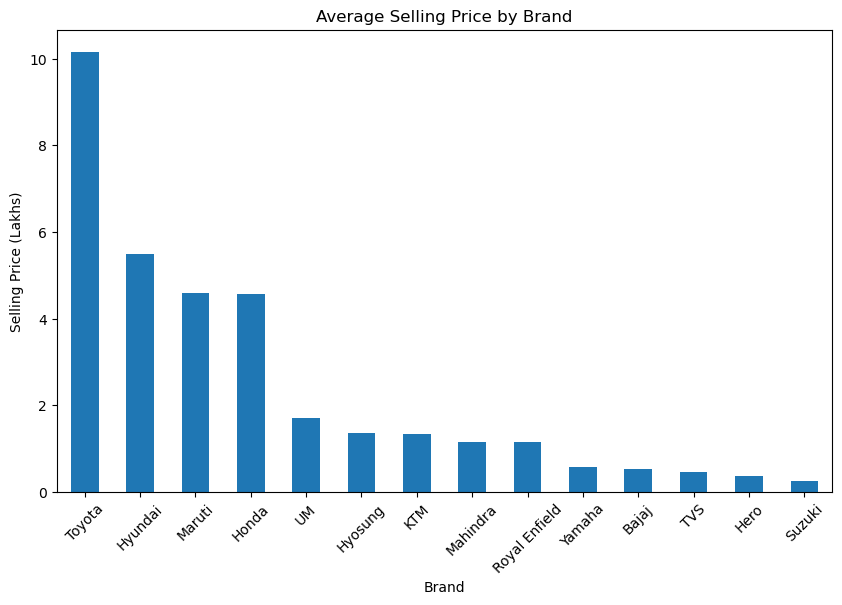

In [84]:
brand_price = (
    df.groupby("Brand")["Selling_Price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
brand_price.plot(kind="bar")

plt.title("Average Selling Price by Brand")
plt.ylabel("Selling Price (Lakhs)")
plt.xticks(rotation=45)

plt.show()

INTEPRETATION

The above graph shows the selling prices of the cars by brand, we see that Toyota cars resell best, followed by Hyundai and Suzuki the worst, this is because the dataset contains quite expensive Toyota cars. 

### Average present price for each car brand 

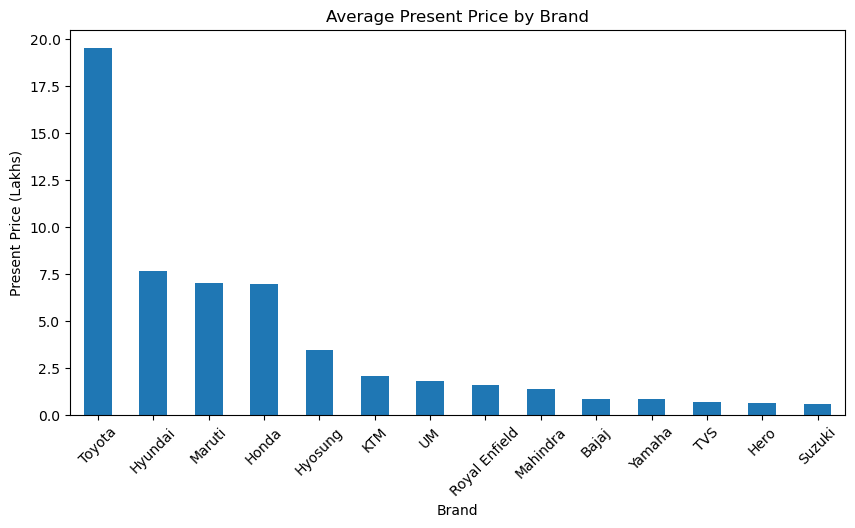

In [85]:
present_brand = (
    df.groupby("Brand")["Present_Price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
present_brand.plot(kind="bar")

plt.title("Average Present Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Present Price (Lakhs)")
plt.xticks(rotation=45)

plt.show()

INTEPRETATION

The above graph shows the present prices of the cars by brand, we see that Toyota cars are most expensive, followed by Hyundai and Suzuki the least. The relation between the two graphs seem to linear, cars with the highest resell value have the highest present prices.

### Average depreciation value for each brand 

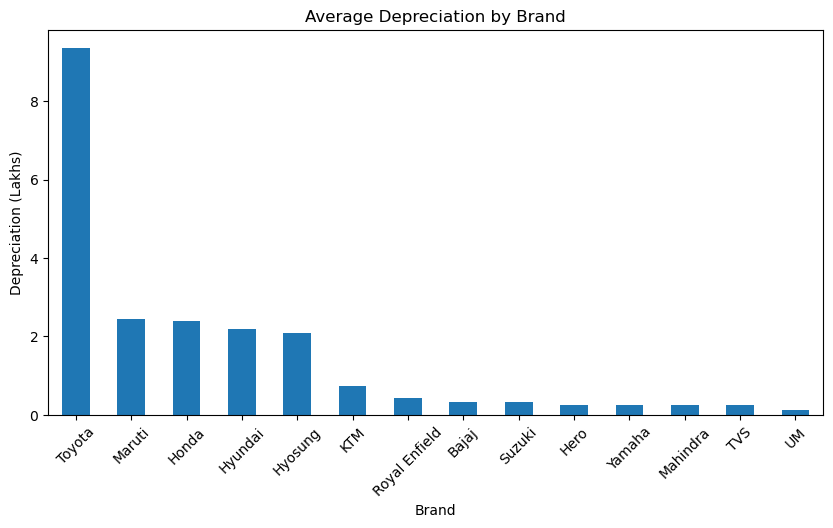

In [86]:
depreciation_brand = (
    df.groupby("Brand")["Depreciation"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
depreciation_brand.plot(kind="bar")

plt.title("Average Depreciation by Brand")
plt.xlabel("Brand")
plt.ylabel("Depreciation (Lakhs)")
plt.xticks(rotation=45)

plt.show()

INTEPRETATION:

The above graph shows the average depreciation value by each car brand. We can deduce that Toyota has the highest average depreciation value and this may be due to how expensive Toyota models are in show rooms. UM and TVS showed the least depreciation value.  

### How does driven kilometres affect the car selling price?

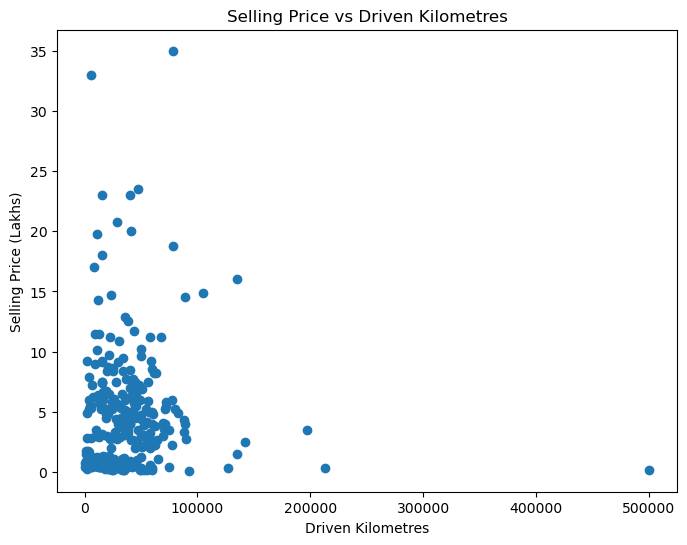

In [87]:
plt.figure(figsize=(8,6))

plt.scatter(df["Driven_kms"], df["Selling_Price"])

plt.title("Selling Price vs Driven Kilometres")
plt.xlabel("Driven Kilometres")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

INTEPRETATION:

We observe from the scatter plot that most used cars are sold for less than 15 lakhs. The relationship between driven kilometres and selling price is not clearly linear, making it difficult to conclude that higher mileage alone leads to lower selling prices. This suggests that other factors also contribute to the resale value of a used car.
A few outliers are visible in the dataset, including a car with extremely high mileage (around 500,000 km) and several cars with unusually high selling prices despite moderate mileage. These points may represent exceptional cases and could affect the performance of regression models if left untreated.



### How does the age of the car affect its selling price?

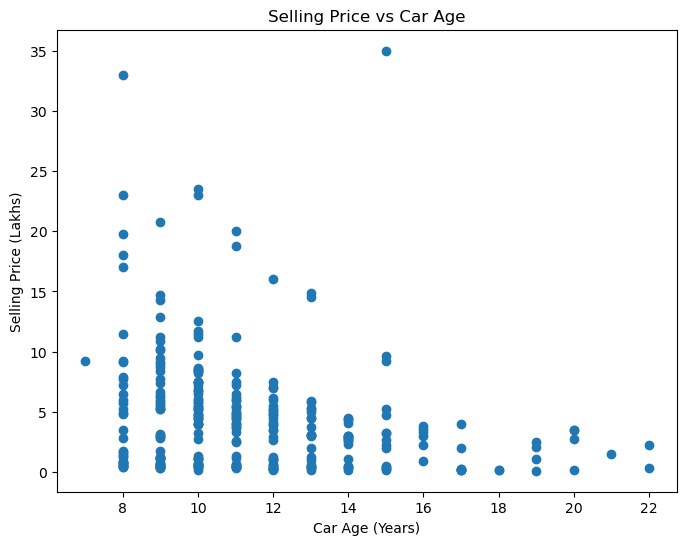

In [88]:
plt.figure(figsize=(8,6))

plt.scatter(df["Car_Age"], df["Selling_Price"])

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

INTEPRETATION:

From the above scatter plot we can tell that there is a strong negative corelation between the car age and its selling price. We can deduce that, the older the car the cheaper it is and the opposite is true. We can clearly see that the younger cars resale value could go all the way up to 25 Lakhs while the older cars selling prices are below 5 Lakhs. Therefore, the older the car, the lower the selling price.

### How present price affects selling price

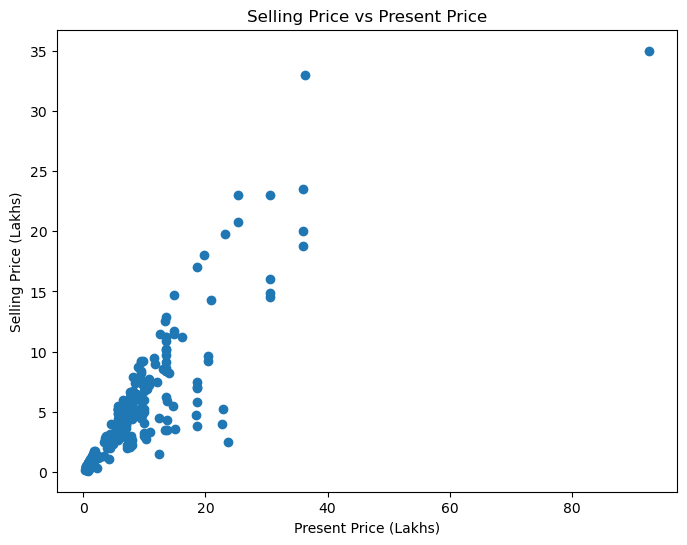

In [89]:
plt.figure(figsize=(8,6))

plt.scatter(df["Present_Price"], df["Selling_Price"])

plt.title("Selling Price vs Present Price")
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

INTEPRETATION:

The scatter plot shows a strong positive linear relationship between the present price and the selling price of used cars. As the present price increases, the selling price also tends to increase. This indicates that vehicles with a higher original market value generally retain a higher resale value. The points generally follow an upward trend from the bottom-left to the top-right, indicating a strong positive correlation.
Most cars are clustered in the lower price range, with only a few expensive vehicles appearing as outliers.


### Corelation analysis

In [90]:
corr = df[
    [
        "Selling_Price",
        "Present_Price",
        "Driven_kms",
        "Car_Age",
        "Owner",
        "Depreciation",
        "Depreciation_%"
    ]
].corr()

print(corr.round(2))

                Selling_Price  Present_Price  Driven_kms  Car_Age  Owner  \
Selling_Price            1.00           0.88        0.03    -0.23  -0.09   
Present_Price            0.88           1.00        0.21     0.05   0.01   
Driven_kms               0.03           0.21        1.00     0.53   0.09   
Car_Age                 -0.23           0.05        0.53     1.00   0.18   
Owner                   -0.09           0.01        0.09     0.18   1.00   
Depreciation             0.52           0.87        0.33     0.34   0.11   
Depreciation_%          -0.23           0.11        0.51     0.85   0.22   

                Depreciation  Depreciation_%  
Selling_Price           0.52           -0.23  
Present_Price           0.87            0.11  
Driven_kms              0.33            0.51  
Car_Age                 0.34            0.85  
Owner                   0.11            0.22  
Depreciation            1.00            0.43  
Depreciation_%          0.43            1.00  


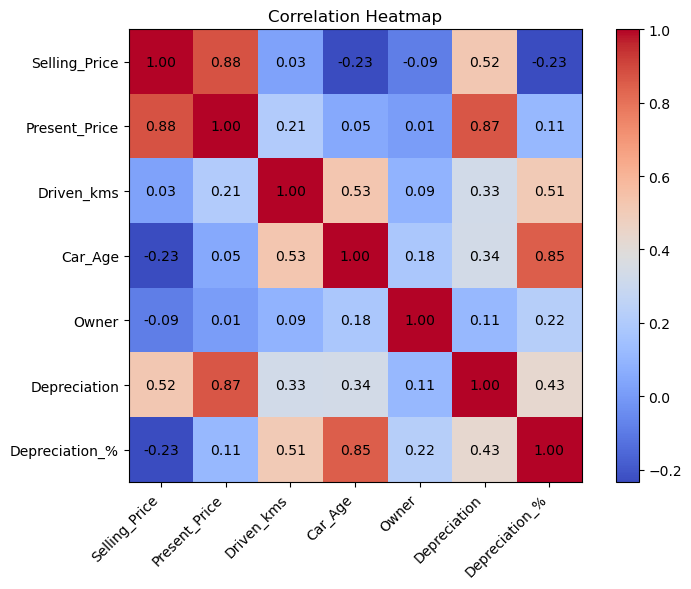

In [91]:
corr = df[[
    "Selling_Price",
    "Present_Price",
    "Driven_kms",
    "Car_Age",
    "Owner",
    "Depreciation",
    "Depreciation_%"
]].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

INTEPRETATION:

The correlation matrix shows that Present Price has the strongest positive correlation with Selling Price, indicating that vehicles with higher showroom prices generally have higher resale values. Car Age, Owner, and Depreciation Percentage exhibit negative correlations with Selling Price, suggesting that older vehicles, cars with more previous owners, and vehicles with greater depreciation tend to have lower resale values. The remaining variables show relatively weak correlations, indicating a smaller linear relationship with the selling price.

### Selling price vs transmission, selling type and fuel type

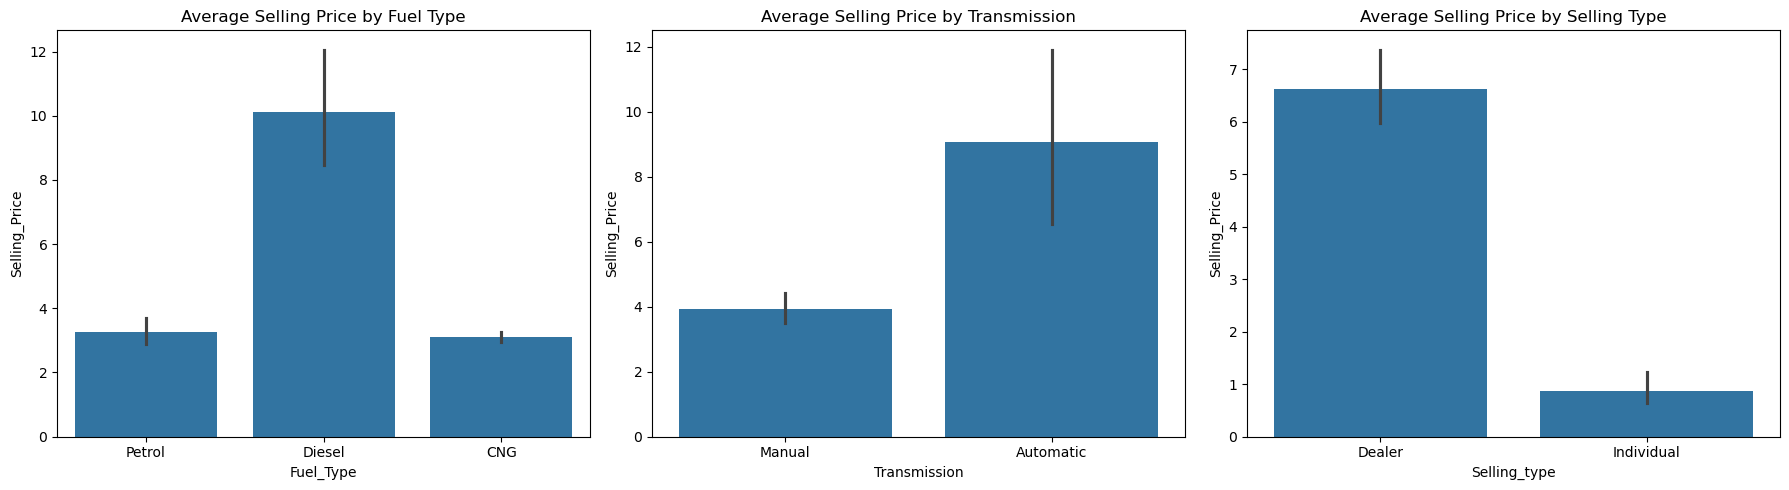

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df,
    estimator="mean",
    ax=axes[0]
)
axes[0].set_title("Average Selling Price by Fuel Type")

sns.barplot(
    x="Transmission",
    y="Selling_Price",
    data=df,
    estimator="mean",
    ax=axes[1]
)
axes[1].set_title("Average Selling Price by Transmission")

sns.barplot(
    x="Selling_type",
    y="Selling_Price",
    data=df,
    estimator="mean",
    ax=axes[2]
)
axes[2].set_title("Average Selling Price by Selling Type")

plt.tight_layout()
plt.show()

INTEPRETATION:

Diesel vehicles have the highest average selling price in the dataset. Petrol and CNG vehicles generally sell for lower prices. This suggests that fuel type influences resale value, although the CNG category contains very few observations, so conclusions about CNG should be interpreted with caution.
Cars sold through dealers have significantly higher average selling prices than those sold by individual owners. This may be because dealers often sell newer, higher-value vehicles or include additional services such as inspections and warranties.
Automatic transmission vehicles have a substantially higher average selling price than manual vehicles. This indicates that transmission type is an important factor affecting resale value, with automatic cars generally commanding higher prices.

# Machine Learning Model

After EDA, in this section, the dataset is prepared for training by encoding categorical variables, splitting the data into training and testing sets, training regression models, and evaluating their performance in predicting the selling price of used cars.

## Feature selection

We have to remove unnecessary features and also those variables derived from the target variable (Selling Price to prevent data leakage during model training.

In [93]:
df_ml = df.copy()
df_ml = df_ml.drop(
    columns=[
        "Car_Name",
        "Year",
        "Depreciation",
        "Depreciation_%"
    ]
)

df_ml.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,Maruti
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,Maruti
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,Maruti
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,Maruti
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,Maruti


### Encoding

Because ML models cannot handle categorical or string data types, we have to convert them to nuumerical data.

In [94]:
df_ml = pd.get_dummies(
    df_ml,
    columns=[
        "Fuel_Type",
        "Selling_type",
        "Transmission",
        "Brand"
    ],
    drop_first=True
)

df_ml.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Brand_Hero,...,Brand_Hyundai,Brand_KTM,Brand_Mahindra,Brand_Maruti,Brand_Royal Enfield,Brand_Suzuki,Brand_TVS,Brand_Toyota,Brand_UM,Brand_Yamaha
0,3.35,5.59,27000,0,11,False,True,False,True,False,...,False,False,False,True,False,False,False,False,False,False
1,4.75,9.54,43000,0,12,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,7.25,9.85,6900,0,8,False,True,False,True,False,...,False,False,False,True,False,False,False,False,False,False
3,2.85,4.15,5200,0,14,False,True,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,4.60,6.87,42450,0,11,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False


In [95]:
df_ml.columns

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual', 'Brand_Hero', 'Brand_Honda', 'Brand_Hyosung',
       'Brand_Hyundai', 'Brand_KTM', 'Brand_Mahindra', 'Brand_Maruti',
       'Brand_Royal Enfield', 'Brand_Suzuki', 'Brand_TVS', 'Brand_Toyota',
       'Brand_UM', 'Brand_Yamaha'],
      dtype='object')

In [96]:
bool_cols = df_ml.select_dtypes(include='bool').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

df_ml.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Brand_Hero,...,Brand_Hyundai,Brand_KTM,Brand_Mahindra,Brand_Maruti,Brand_Royal Enfield,Brand_Suzuki,Brand_TVS,Brand_Toyota,Brand_UM,Brand_Yamaha
0,3.35,5.59,27000,0,11,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,4.75,9.54,43000,0,12,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,7.25,9.85,6900,0,8,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
3,2.85,4.15,5200,0,14,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,4.60,6.87,42450,0,11,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


### Defining Target variable

In [97]:

X = df_ml.drop("Selling_Price", axis=1)

# Target
y = df_ml["Selling_Price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (299, 21)
Target shape: (299,)


### Train-Test Split

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [99]:
print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)

Training features: (239, 21)
Testing features : (60, 21)
Training target: (239,)
Testing target : (60,)


The dataset was divided into training and testing sets using an 80:20 ratio. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data. A fixed random state of 42 was used to ensure reproducibility of the results.

## Linear Regression Model

Linear Regression is used as the baseline regression model to predict the selling price of used cars. The model learns the relationship between the input features and the target variable using the training dataset.

In [100]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [101]:
y_pred = lr_model.predict(X_test)

y_pred[:10]

array([ 7.47321068,  7.7743543 ,  1.75830653,  6.79599813, 11.37968014,
        4.56110727,  8.73299676,  1.87300133,  8.61895264, -0.60265866])

In [102]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1.51
Mean Squared Error (MSE): 6.43
Root Mean Squared Error (RMSE): 2.54
R² Score: 0.7504


### Interpretation

The Linear Regression model was evaluated using four performance metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² Score. The Linear Regression model achieved a Mean Absolute Error (MAE) of **1.51 lakhs**, indicating that the predicted selling prices differ from the actual values by approximately 1.51 lakhs on average. The model obtained an RMSE of **2.54 lakhs**, suggesting the presence of some larger prediction errors. The R² score of **0.7504** indicates that the model explains approximately **75%** of the variation in selling prices. Overall, the Linear Regression model provides a reasonable baseline for predicting used car selling prices.

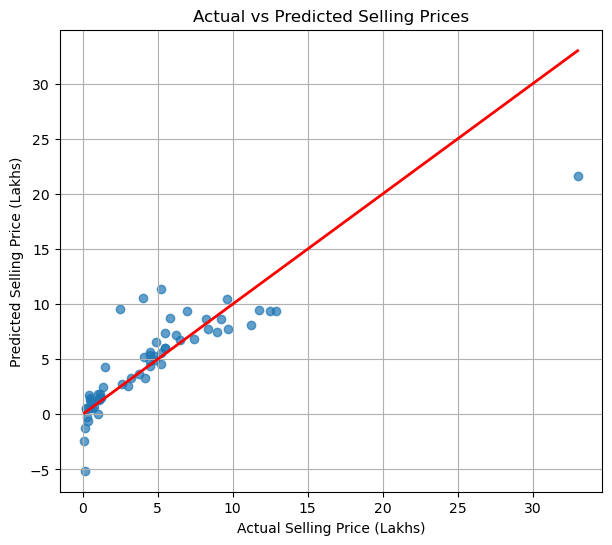

In [103]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Selling Price (Lakhs)")
plt.ylabel("Predicted Selling Price (Lakhs)")
plt.title("Actual vs Predicted Selling Prices")

plt.grid(True)

plt.show()

## Decision Tree Regression

Decision Tree Regression is a non-linear machine learning algorithm that predicts the selling price by recursively splitting the dataset into smaller groups based on the input features. Unlike Linear Regression, it can capture complex and non-linear relationships between the variables.

In [104]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [105]:
y_pred_dt = dt_model.predict(X_test)

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = mse_dt ** 0.5

r2_dt = r2_score(y_test, y_pred_dt)

print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R² Score: {r2_dt:.4f}")

Mean Absolute Error (MAE): 1.36
Mean Squared Error (MSE): 9.09
Root Mean Squared Error (RMSE): 3.02
R² Score: 0.6472


### Interpretation

The Decision Tree Regression model achieved a lower MAE than the Linear Regression model, indicating slightly better average prediction accuracy. However, it produced a higher RMSE and a lower R² score, suggesting that the model made some larger prediction errors and explained less of the variation in selling prices. Overall, the Decision Tree did not outperform the Linear Regression model on this dataset.

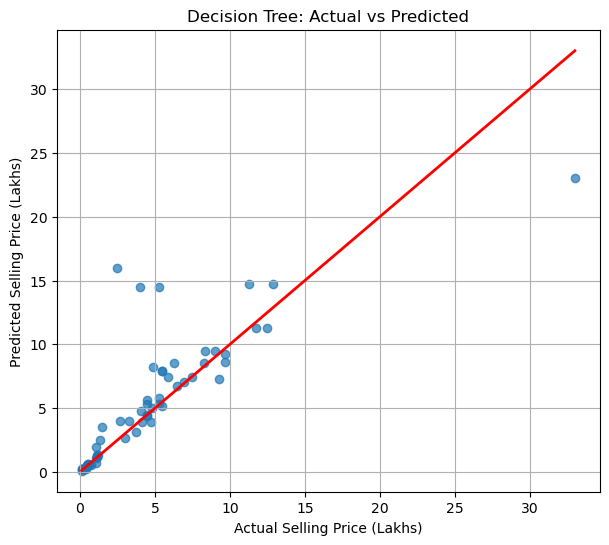

In [107]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_dt, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Selling Price (Lakhs)")
plt.ylabel("Predicted Selling Price (Lakhs)")
plt.title("Decision Tree: Actual vs Predicted")

plt.grid(True)
plt.show()

## Random Forest Regression

Random Forest Regression is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It generally provides more robust and reliable predictions than a single decision tree.

In [108]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
y_pred_rf = rf_model.predict(X_test)

In [110]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = mse_rf ** 0.5

r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")

Mean Absolute Error (MAE): 1.39
Mean Squared Error (MSE): 11.34
Root Mean Squared Error (RMSE): 3.37
R² Score: 0.5601


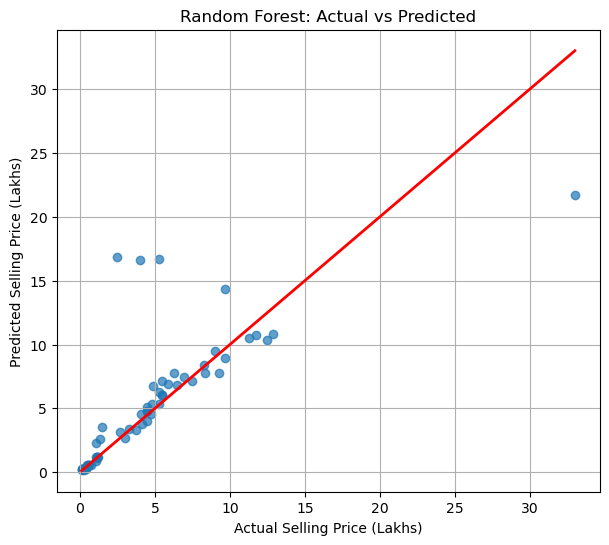

In [111]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Selling Price (Lakhs)")
plt.ylabel("Predicted Selling Price (Lakhs)")
plt.title("Random Forest: Actual vs Predicted")

plt.grid(True)
plt.show()

In [112]:
print(rf_model.score(X_train, y_train))
print(rf_model.score(X_test, y_test))

0.9836221773146302
0.560140999888946


### Intepretation:
Despite Random Forest being the most advanced regression model, we can see that the model suffered from overfitting. The training accuracy is high at 98% with a testing accuracy of 56%. Model is not able to perform on unseen data as it has memorised the training dataset. This may be due to the fact that the datset is quite small of only 300 records. Model shows high variance.

## Feature Importance

Although Random Forest was not the best-performing model, it provides feature importance scores that indicate which variables contributed the most to predicting the selling price of used cars.


In [113]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
0,Present_Price,9.065898e-01
3,Car_Age,6.915004e-02
1,Driven_kms,1.242634e-02
7,Transmission_Manual,5.159845e-03
6,Selling_type_Individual,1.512372e-03
18,Brand_Toyota,1.427495e-03
9,Brand_Honda,1.195860e-03
4,Fuel_Type_Diesel,9.028121e-04
11,Brand_Hyundai,7.006107e-04
5,Fuel_Type_Petrol,5.810783e-04


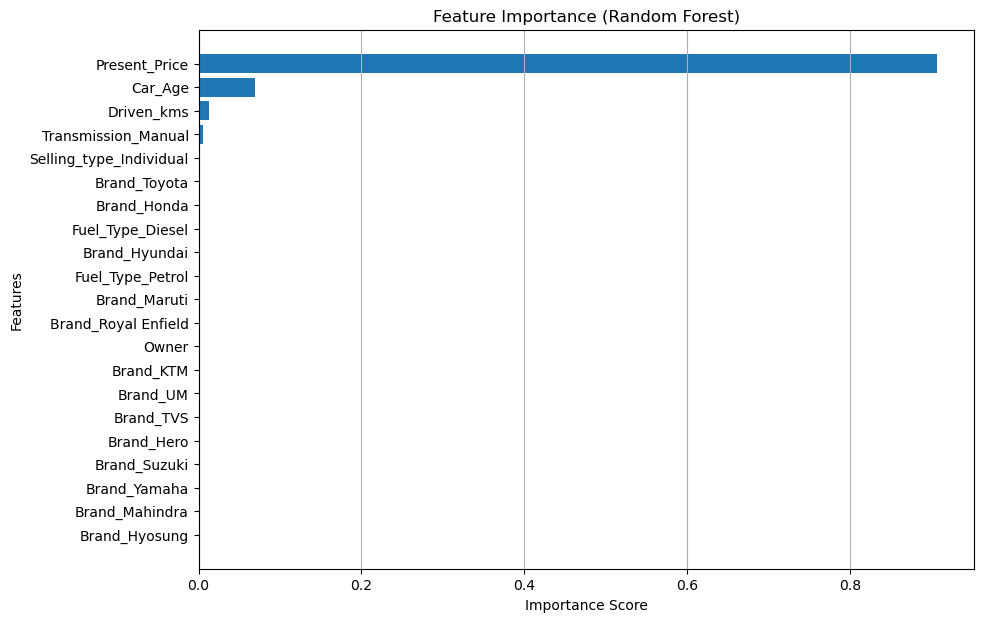

In [114]:
plt.figure(figsize=(10,7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.show()

### Interpretation

The feature importance analysis shows the variables that contributed the most to predicting the selling price of used cars. As expected, **Present Price** is the most influential feature, followed by variables such as **Car Age**, **Driven Kilometres**, and selected vehicle characteristics. Features with very low importance contribute little to the prediction and have a smaller impact on the model's performance.

## Model Comparison

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae, mae_dt, mae_rf],
    "RMSE": [rmse, rmse_dt, rmse_rf],
    "R2 Score": [r2, r2_dt, r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.513763,2.536500,0.750368
1,Decision Tree,1.364667,3.015336,0.647221
2,Random Forest,1.393940,3.366987,0.560141


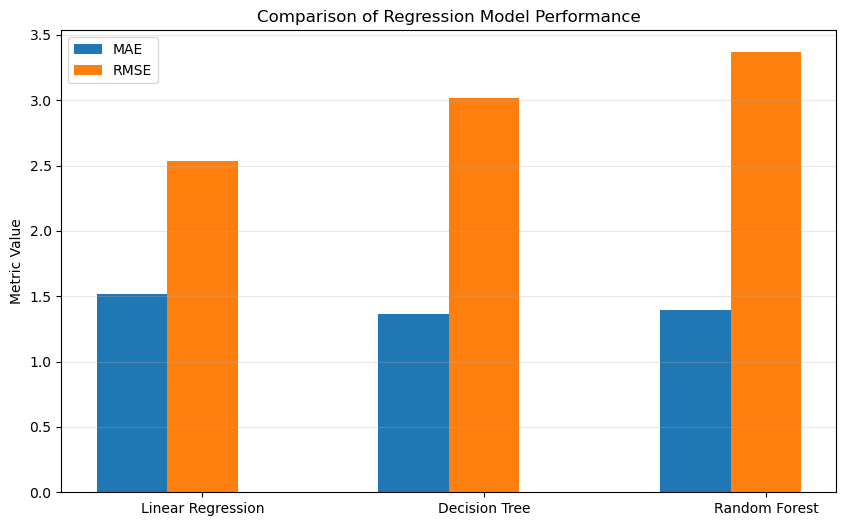

In [116]:
x = np.arange(len(results["Model"]))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, results["MAE"], width, label="MAE")
plt.bar(x, results["RMSE"], width, label="RMSE")

plt.xticks(x, results["Model"])
plt.ylabel("Metric Value")
plt.title("Comparison of Regression Model Performance")
plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
results_r2 = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R² Score": [r2, r2_dt, r2_rf]
})

plt.figure(figsize=(8,6))

bars = plt.bar(results_r2["Model"], results_r2["R² Score"])

plt.ylabel("R² Score")
plt.title("Comparison of Model Accuracy (R²)")
plt.ylim(0,1)

# Display values above bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

### Intepretation
Three regression models were developed and evaluated to predict used car selling prices. Although the Decision Tree achieved the lowest Mean Absolute Error (MAE), it produced larger overall prediction errors, resulting in a lower R² score. The Random Forest model showed clear signs of overfitting, achieving a training R² score of 0.9836 but only 0.5601 on the test data. Among the three models, Linear Regression achieved the highest test R² score (0.7504) and the lowest RMSE (2.54), making it the best-performing model for this dataset.

The bar chart compares the performance of the three regression models using MAE, RMSE, and R² Score. Linear Regression achieved the highest R² score and the lowest RMSE, indicating the best overall predictive performance. Although the Decision Tree model recorded the lowest MAE, it had a lower R² score and a higher RMSE than Linear Regression. The Random Forest model performed the worst on the test dataset, suggesting that it overfitted the training data.

## Model demonstration

To demonstrate the practical application of the trained model, a sample observation from the test dataset was selected. The model predicts the selling price of the vehicle using its characteristics, and the predicted value is compared with the actual selling price.

In [ ]:
sample = X_test.iloc[[0]]

prediction = lr_model.predict(sample)

print("Predicted Selling Price:", prediction[0], "Lakhs")
print("Actual Selling Price:", y_test.iloc[0], "Lakhs")

## Conclusion 
This project applied Exploratory Data Analysis (EDA) and machine learning techniques to investigate the factors influencing the selling price of used cars and to develop a predictive model.
The exploratory analysis revealed that **Present Price** is the strongest factor associated with **Selling Price**, while **Car Age**, **Driven Kilometres**, **Owner**, and **Depreciation Percentage** also influence a vehicle's resale value. Additional analysis of categorical variables such as **Fuel Type**, **Transmission**, and **Selling Type** provided further insights into how different vehicle characteristics affect selling prices.

Three regression models were developed and evaluated: **Linear Regression**, **Decision Tree Regression**, and **Random Forest Regression**. Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² Score. Among the three models, **Linear Regression** achieved the best overall performance.

Overall, this project demonstrates the importance of data preprocessing, feature engineering, exploratory analysis, and model comparison in developing reliable machine learning solutions. The findings also show that, for this dataset, a simpler model such as Linear Regression can outperform more complex algorithms when the underlying relationships are predominantly linear.